In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Đọc dữ liệu từ file CSV
df1 = pd.read_csv('train_bi.csv')
df2 = pd.read_csv('ket_qua.csv')

Phân tích giao dịch & Phân loại ABC 

In [4]:
#Phân tích hành vi trả hàng 
returns =df2[df2['Quantity']<0]
print(f"Tổng số giao dịch trả hàng: {len(returns)}")
print(f"Tổng số lượng hàng bị trả lại: {returns['Quantity'].sum()}")

Tổng số giao dịch trả hàng: 37246
Tổng số lượng hàng bị trả lại: -86578


In [6]:
# 3. Phân loại ABC dựa trên tổng doanh thu thực tế của từng SKU
# Gom nhóm để tính tổng Doanh thu (SalesAmount) của mỗi mã sản phẩm
sales_by_sku = df2.groupby('ItemCode')['SalesAmount'].sum().reset_index()
sales_by_sku = sales_by_sku.sort_values(by='SalesAmount', ascending=False)
# Tính % tích lũy doanh thu
sales_by_sku['CumulativeSales'] = sales_by_sku['SalesAmount'].cumsum()
sales_by_sku['CumulativePercentage'] = sales_by_sku['CumulativeSales'] / sales_by_sku['SalesAmount'].sum() * 100

# Gán nhãn nhóm hàng A, B, C
def assign_abc(pct):
    if pct <= 80: return 'A'  # Nhóm A: 80% doanh thu đầu tiên
    elif pct <= 95: return 'B' # Nhóm B: 15% doanh thu tiếp theo
    else: return 'C' # Nhóm C: 5% doanh thu còn lại

sales_by_sku['ABC_Class'] = sales_by_sku['CumulativePercentage'].apply(assign_abc)
print(" KẾT QUẢ PHÂN LOẠI PHO KHO HÀNG")
print(sales_by_sku['ABC_Class'].value_counts())


--- KẾT QUẢ PHÂN LOẠI PHO KHO HÀNG ---
ABC_Class
C    10939
B     3491
A     1542
Name: count, dtype: int64


Phân tích tính mùa vụ và chu kì dựa trên file train_bi.csv

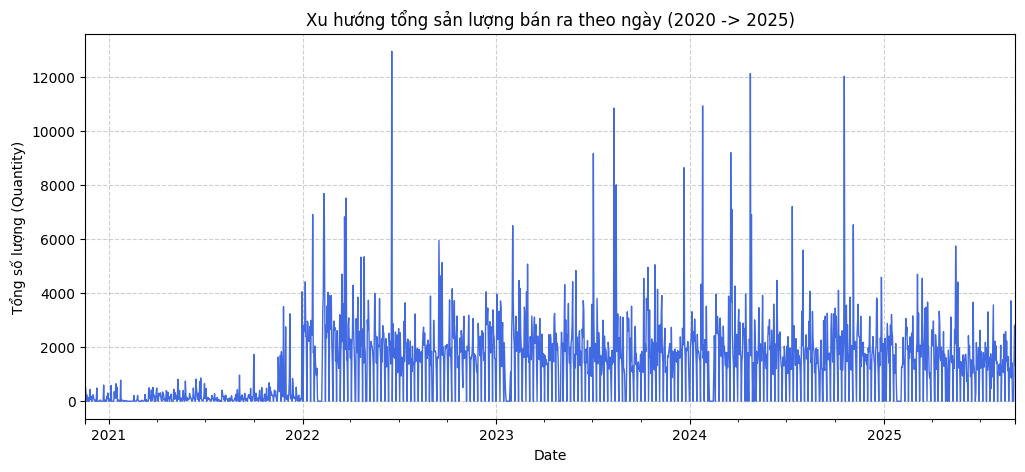

In [16]:

#2. Trích xuất các thuộc tính thời gian cơ bản để phân tích
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')
df1['DayOfWeek'] = df1['Date'].dt.dayofweek  # 0: Thứ 2 -> 6: Chủ Nhật
df1['Month'] = df1['Date'].dt.month
df1['Year'] = df1['Date'].dt.year

# 3. Biểu đồ xu hướng (Trend) theo từng năm của toàn hệ thống
plt.figure(figsize=(12, 5))
df1.groupby('Date')['Quantity'].sum().plot(color='royalblue', linewidth=1)
plt.title('Xu hướng tổng sản lượng bán ra theo ngày (2020 -> 2025)')
plt.ylabel('Tổng số lượng (Quantity)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



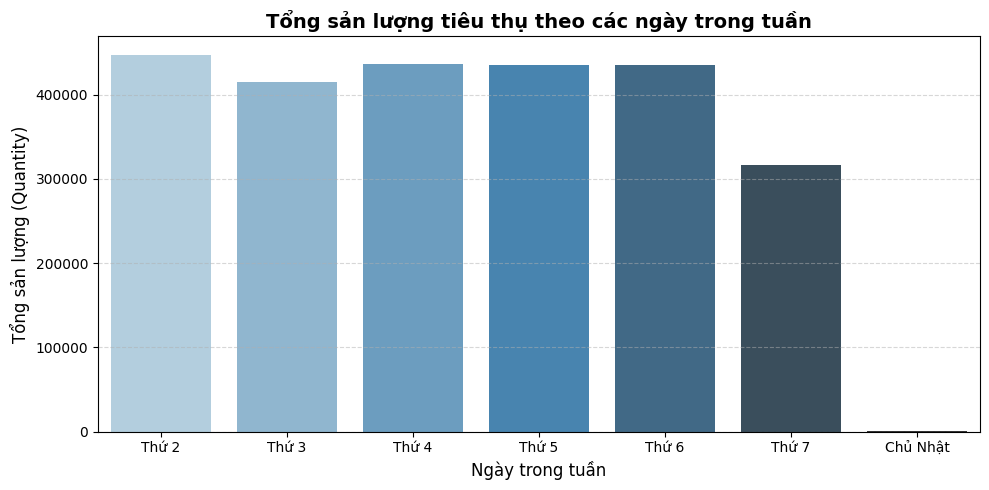

In [33]:
plt.figure(figsize=(10, 5))
weekly_summary = df1.groupby('DayOfWeek')['Quantity'].sum().reset_index()
sns.barplot(
    data=weekly_summary, 
    x='DayOfWeek', 
    y='Quantity', 
    hue='DayOfWeek',         
    palette='Blues_d',          
    legend=False             
)
plt.title('Tổng sản lượng tiêu thụ theo các ngày trong tuần', fontsize=14, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Tổng sản lượng (Quantity)', fontsize=12)
plt.xticks(ticks=range(7), labels=['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật'])
plt.grid(axis='y', linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show()

Phân tích tìm Biến trễ (lag)

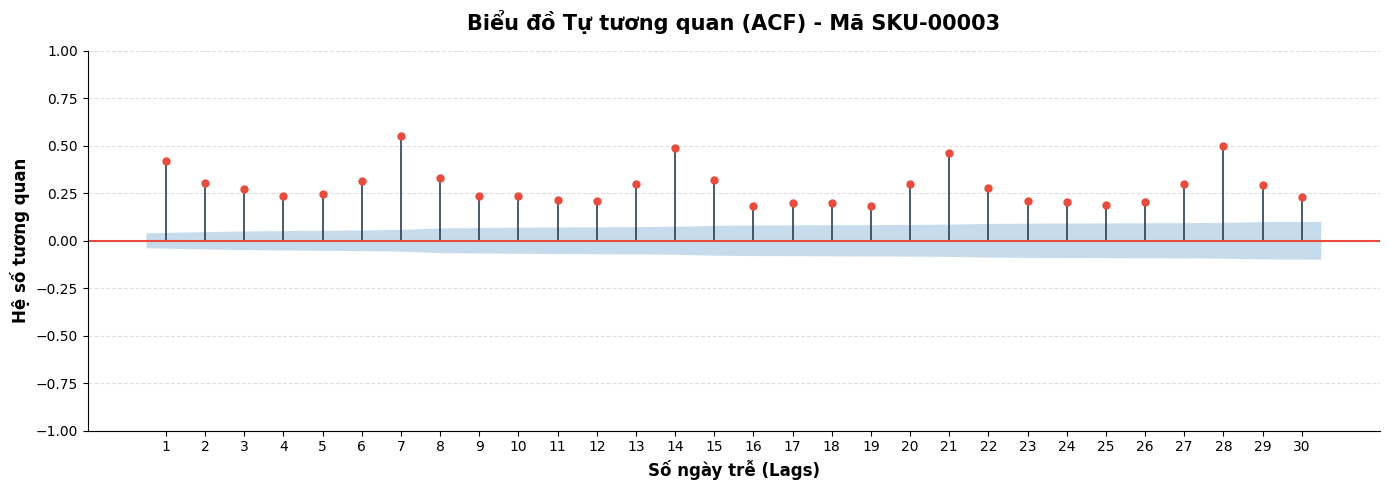

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
#Thực hiện phân tích tự tương quan (ACF) cho mã sản phẩm có doanh thu cao nhất
top_sku = sales_by_sku.iloc[0]['ItemCode']
sku_series = df1[df1['ItemCode'] == top_sku].sort_values('Date')
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(
    sku_series['Quantity'], 
    lags=30, 
    ax=ax, 
    zero=False,                               
    color='#e74c3c',                         
    vlines_kwargs={'colors': '#2c3e50', 'linewidth': 1.2}, 
    alpha=0.1                                
)
ax.set_title(f'Biểu đồ Tự tương quan (ACF) - Mã {top_sku}', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Số ngày trễ (Lags)', fontsize=12, fontweight='bold')
ax.set_ylabel('Hệ số tương quan', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)            
ax.spines['right'].set_visible(False)          
ax.set_xticks(range(1, 31))                    
ax.grid(axis='y', linestyle='--', alpha=0.4) 
plt.tight_layout()
plt.show()

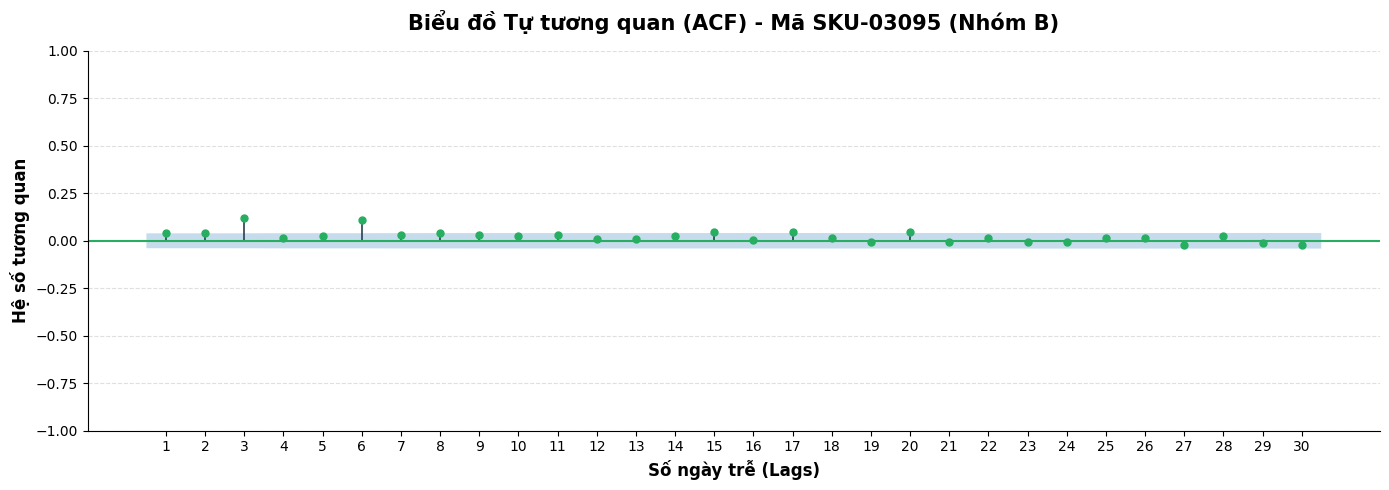

In [34]:
#Thực hiện tương quan đối với mã sản phẩm thuộc nhóm B 
top_sku_b = sales_by_sku[sales_by_sku['ABC_Class'] == 'B'].iloc[0]['ItemCode']
sku_series_b = df1[df1['ItemCode'] == top_sku_b].sort_values('Date')
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(
    sku_series_b['Quantity'], 
    lags=30, 
    ax=ax, 
    zero=False,                               
    color='#27ae60',                         
    vlines_kwargs={'colors': '#2c3e50', 'linewidth': 1.2}, 
    alpha=0.1                                
)
ax.set_title(f'Biểu đồ Tự tương quan (ACF) - Mã {top_sku_b} (Nhóm B)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Số ngày trễ (Lags)', fontsize=12, fontweight='bold')
ax.set_ylabel('Hệ số tương quan', fontsize=12, fontweight='bold')   
ax.spines['top'].set_visible(False)            
ax.spines['right'].set_visible(False)   
ax.set_xticks(range(1, 31))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
